In [1]:
# ============================================
# Lab - EDA Univariate Analysis: Amazon UK Products
# Dataset: https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/
# ============================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# -------------------------
# 1) Point to your dataset
# -------------------------
# Put the path to your unzipped CSV file here
DATA_PATH = r"/Users/manish/Documents/Ironhack/EDA_univariate/lab-eda-univariate/amz_uk_price_prediction_dataset.csv"  # <-- CHANGE THIS

def find_csv(path: str) -> str:
    """Find the first CSV file in a directory or validate a direct CSV path."""
    if os.path.isfile(path) and path.lower().endswith(".csv"):
        return path
    if os.path.isdir(path):
        csvs = sorted(glob.glob(os.path.join(path, "*.csv")))
        if not csvs:
            raise FileNotFoundError(f"No CSV files found in directory: {path}")
        return csvs[0]
    raise FileNotFoundError(f"DATA_PATH not found: {path}")

csv_path = find_csv(DATA_PATH)
print("Using CSV:", csv_path)

# Robust read: handles most CSVs; adjust encoding if needed
df = pd.read_csv(csv_path, low_memory=False)

print("\nShape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
df.head()

Using CSV: /Users/manish/Documents/Ironhack/EDA_univariate/lab-eda-univariate/amz_uk_price_prediction_dataset.csv

Shape: (2443651, 9)

Columns:
 ['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
# -------------------------
# 2) Helper: find columns
# -------------------------
def find_col(candidates, columns):
    cols_lower = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    # also try partial contains
    for cand in candidates:
        for c in columns:
            if cand.lower() in c.lower():
                return c
    return None

category_col = find_col(["category", "product_category", "main_category"], df.columns)
price_col    = find_col(["price", "product_price", "final_price", "sale_price"], df.columns)
rating_col   = find_col(["rating", "stars", "product_rating"], df.columns)

print("Detected columns:")
print("  category:", category_col)
print("  price   :", price_col)
print("  rating  :", rating_col)

if category_col is None or price_col is None or rating_col is None:
    raise ValueError(
        "Could not detect required columns (category, price, rating). "
        "Please inspect df.columns and update candidate lists accordingly."
    )

# -------------------------
# 3) Clean price and rating
# -------------------------
df_clean = df.copy()

# Make category string-like and clean whitespace
df_clean[category_col] = df_clean[category_col].astype(str).str.strip()

# Convert price to numeric (handles currency symbols, commas, etc.)
df_clean[price_col] = (
    df_clean[price_col]
    .astype(str)
    .str.replace(r"[^\d\.\-]", "", regex=True)   # keep digits, dot, minus
    .replace("", np.nan)
)
df_clean[price_col] = pd.to_numeric(df_clean[price_col], errors="coerce")

# Convert rating to numeric
df_clean[rating_col] = pd.to_numeric(df_clean[rating_col], errors="coerce")

# Basic sanity filters (optional but usually helpful):
# - Remove non-positive prices (if present due to parsing issues)
df_clean = df_clean[df_clean[price_col].isna() | (df_clean[price_col] > 0)]

print("\nAfter cleaning:")
print("Shape:", df_clean.shape)
print("Missing %:")
print(df_clean[[category_col, price_col, rating_col]].isna().mean().mul(100).round(2))

Detected columns:
  category: category
  price   : price
  rating  : stars

After cleaning:
Shape: (2443631, 9)
Missing %:
category    0.0
price       0.0
stars       0.0
dtype: float64


In [3]:
# ============================================
# Part 1: Product categories
# ============================================

cat_counts = df_clean[category_col].value_counts(dropna=True)
cat_freq_table = cat_counts.rename_axis("category").reset_index(name="count")
cat_freq_table["percent"] = (cat_freq_table["count"] / cat_freq_table["count"].sum() * 100).round(2)

print("\nTop 5 categories by listing frequency:")
print(cat_freq_table.head(5))

cat_freq_table.head(20)


Top 5 categories by listing frequency:
                                 category   count  percent
0                       Sports & Outdoors  836260    34.22
1                                  Beauty   19312     0.79
2  Handmade Clothing, Shoes & Accessories   19229     0.79
3                             Bath & Body   19092     0.78
4                          Birthday Gifts   18978     0.78


,category,count,percent
0,Sports & Outdoors,836260,34.22
1,Beauty,19312,0.79
2,"Handmade Clothing, Shoes & Accessories",19229,0.79
3,Bath & Body,19092,0.78
4,Birthday Gifts,18978,0.78
5,Manicure & Pedicure Products,18940,0.78
6,Skin Care,18769,0.77
7,Make-up,18756,0.77
8,Hair Care,18735,0.77
9,Fragrances,18564,0.76


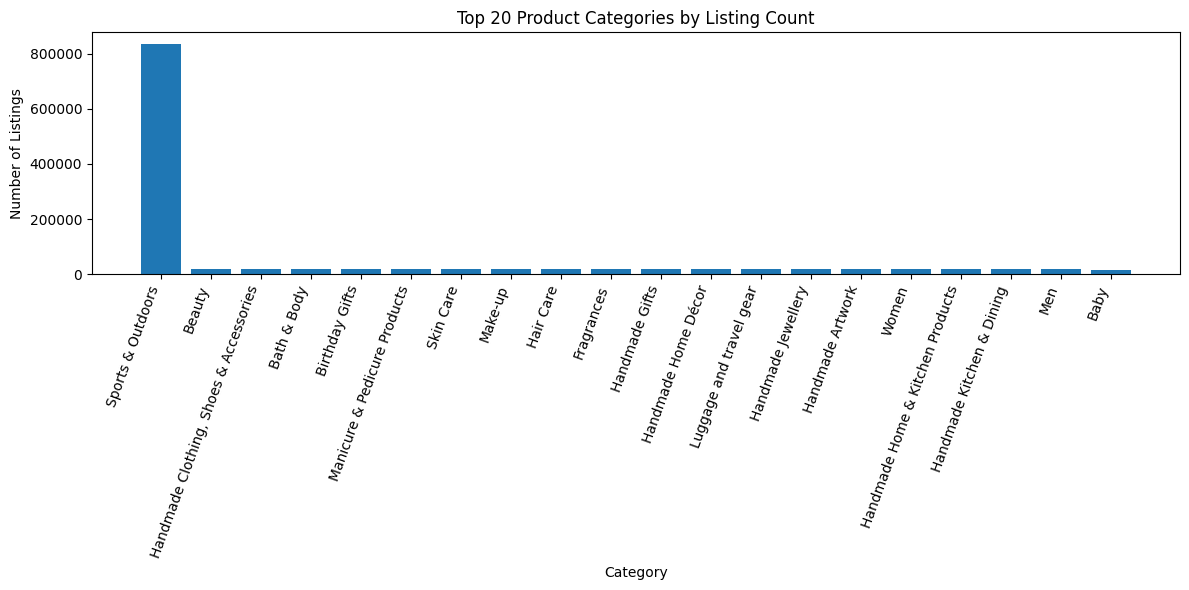

In [4]:
# Bar chart: full set can be unreadable if many categories, so default to top 20
TOP_N = 20
top_cats = cat_freq_table.head(TOP_N)

plt.figure(figsize=(12, 6))
plt.bar(top_cats["category"], top_cats["count"])
plt.title(f"Top {TOP_N} Product Categories by Listing Count")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

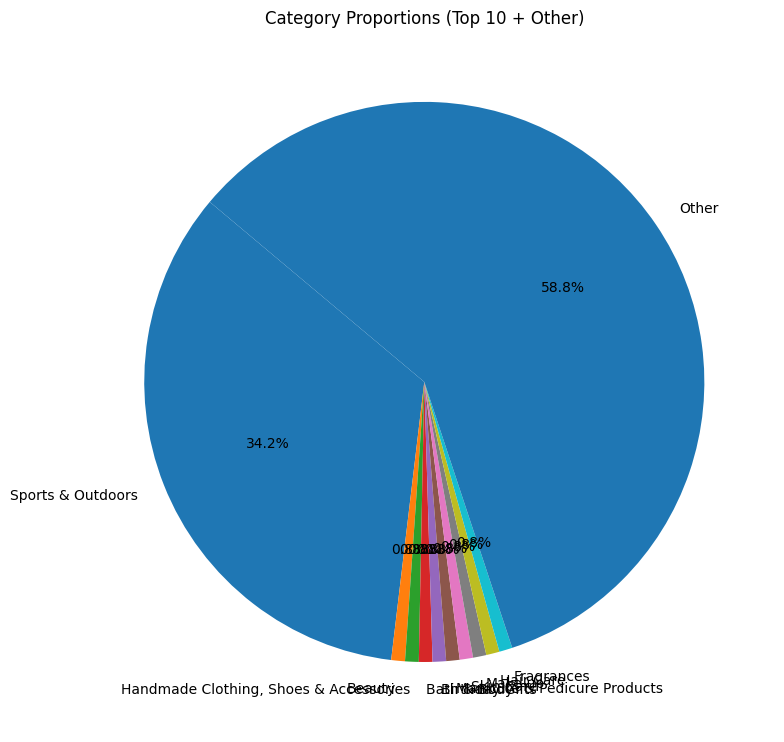


Largest category share: 34.22%


In [5]:
# Pie chart: use top 10 + "Other"
TOP_PIE = 10
pie_df = cat_freq_table.copy()
top = pie_df.head(TOP_PIE).copy()
other_count = pie_df["count"].iloc[TOP_PIE:].sum()
if other_count > 0:
    top = pd.concat([top, pd.DataFrame({"category": ["Other"], "count": [other_count], "percent": [np.nan]})], ignore_index=True)

plt.figure(figsize=(8, 8))
plt.pie(top["count"], labels=top["category"], autopct="%1.1f%%", startangle=140)
plt.title(f"Category Proportions (Top {TOP_PIE} + Other)")
plt.tight_layout()
plt.show()

# Quick check for dominance
dominant_share = (cat_counts.iloc[0] / cat_counts.sum()) * 100
print(f"\nLargest category share: {dominant_share:.2f}%")

In [6]:
# ============================================
# Part 2: Product pricing
# ============================================

price_series = df_clean[price_col].dropna()

price_mean = price_series.mean()
price_median = price_series.median()

# Mode can return multiple values; take the first if exists
price_mode_vals = price_series.mode()
price_mode = price_mode_vals.iloc[0] if len(price_mode_vals) else np.nan

print("\nPricing - Measures of Centrality:")
print(f"Mean  : {price_mean:.4f}")
print(f"Median: {price_median:.4f}")
print(f"Mode  : {price_mode:.4f}")


Pricing - Measures of Centrality:
Mean  : 89.2445
Median: 19.0900
Mode  : 9.9900


In [7]:
price_var = price_series.var(ddof=1)
price_std = price_series.std(ddof=1)
price_range = price_series.max() - price_series.min()
price_iqr = price_series.quantile(0.75) - price_series.quantile(0.25)

print("\nPricing - Measures of Dispersion:")
print(f"Variance: {price_var:.4f}")
print(f"Std Dev : {price_std:.4f}")
print(f"Range   : {price_range:.4f}")
print(f"IQR     : {price_iqr:.4f}")

print("\nPrice quantiles (extra useful context):")
print(price_series.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4))


Pricing - Measures of Dispersion:
Variance: 119446.3977
Std Dev : 345.6102
Range   : 99999.9900
IQR     : 36.0000

Price quantiles (extra useful context):
0.01       2.500
0.05       4.490
0.25       9.990
0.50      19.090
0.75      45.990
0.95     349.515
0.99    1408.820
Name: price, dtype: float64


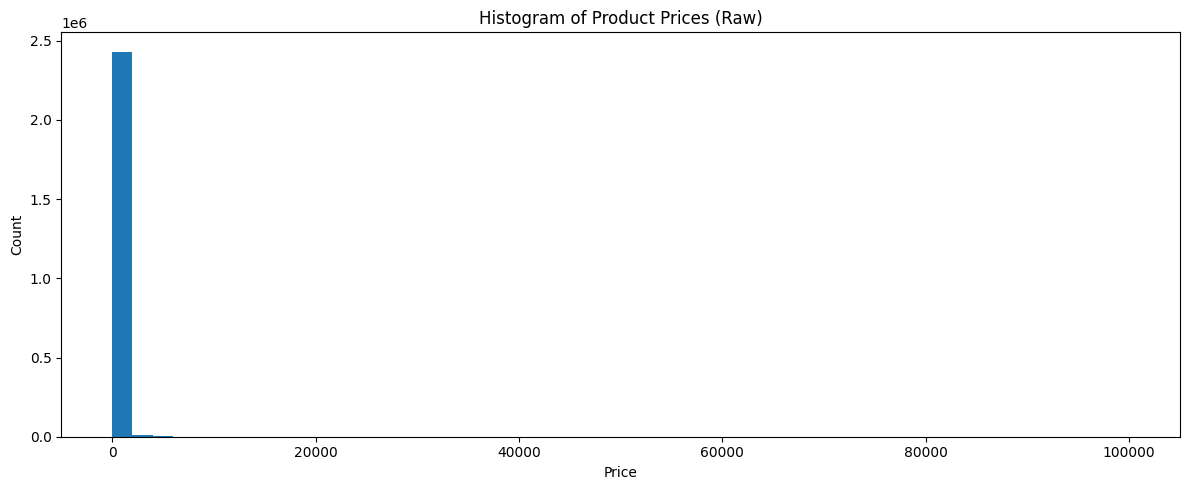

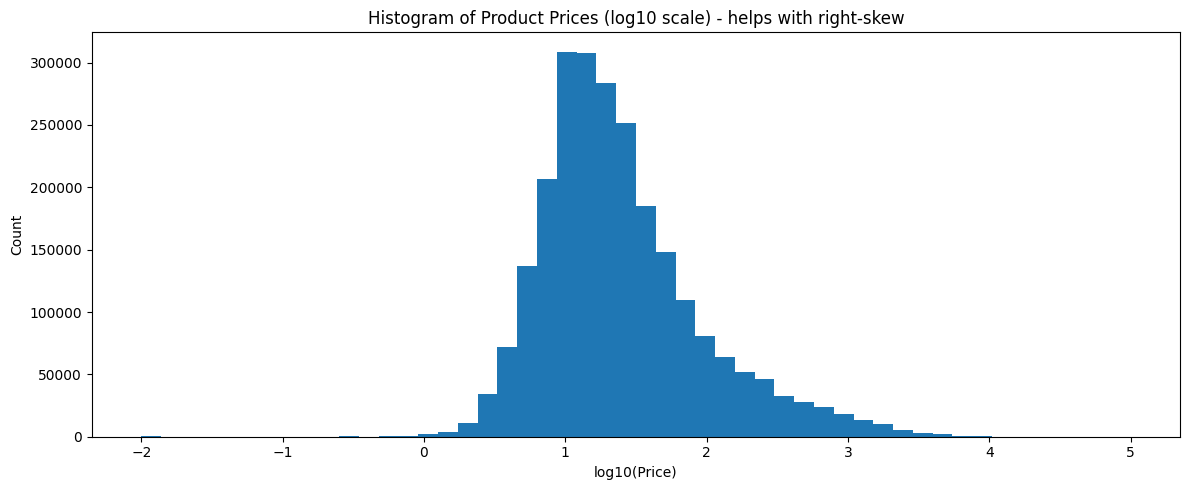

In [8]:
# Histogram: raw prices
plt.figure(figsize=(12, 5))
plt.hist(price_series, bins=50)
plt.title("Histogram of Product Prices (Raw)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# If the histogram is hard to read due to extreme outliers / skew,
# plot a log-scale version (only for positive prices)
price_pos = price_series[price_series > 0]
log_prices = np.log10(price_pos)

plt.figure(figsize=(12, 5))
plt.hist(log_prices, bins=50)
plt.title("Histogram of Product Prices (log10 scale) - helps with right-skew")
plt.xlabel("log10(Price)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

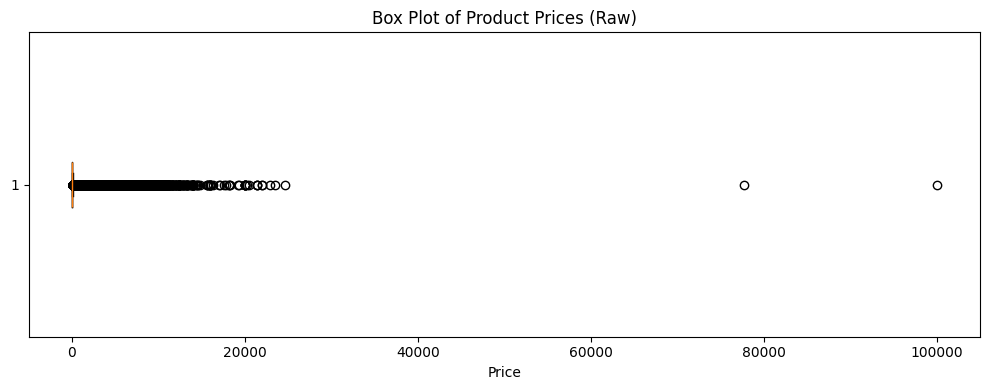

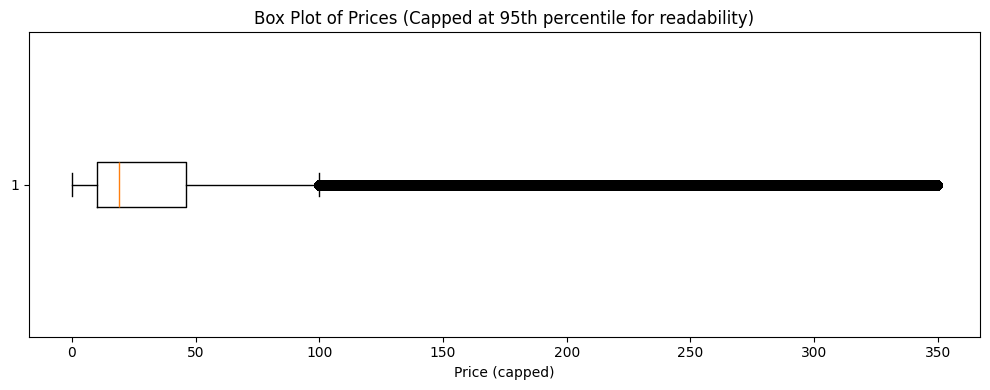


Outlier threshold (upper fence): 99.9900
Share of prices above upper fence: 13.41%


In [9]:
plt.figure(figsize=(10, 4))
plt.boxplot(price_series, vert=False)
plt.title("Box Plot of Product Prices (Raw)")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

# Extra: show "winsorized" view for readability (doesn't change data, only view)
cap = price_series.quantile(0.95)
plt.figure(figsize=(10, 4))
plt.boxplot(price_series.clip(upper=cap), vert=False)
plt.title("Box Plot of Prices (Capped at 95th percentile for readability)")
plt.xlabel("Price (capped)")
plt.tight_layout()
plt.show()

# Identify outliers via 1.5*IQR rule (extra analysis)
q1, q3 = price_series.quantile(0.25), price_series.quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outlier_rate = (price_series > upper_fence).mean() * 100
print(f"\nOutlier threshold (upper fence): {upper_fence:.4f}")
print(f"Share of prices above upper fence: {outlier_rate:.2f}%")

In [10]:
# ============================================
# Part 3: Product ratings
# ============================================

rating_series = df_clean[rating_col].dropna()

rating_mean = rating_series.mean()
rating_median = rating_series.median()

rating_mode_vals = rating_series.mode()
rating_mode = rating_mode_vals.iloc[0] if len(rating_mode_vals) else np.nan

print("\nRatings - Measures of Centrality:")
print(f"Mean  : {rating_mean:.4f}")
print(f"Median: {rating_median:.4f}")
print(f"Mode  : {rating_mode:.4f}")


Ratings - Measures of Centrality:
Mean  : 2.1528
Median: 0.0000
Mode  : 0.0000


In [11]:
rating_var = rating_series.var(ddof=1)
rating_std = rating_series.std(ddof=1)
rating_iqr = rating_series.quantile(0.75) - rating_series.quantile(0.25)

print("\nRatings - Measures of Dispersion:")
print(f"Variance: {rating_var:.4f}")
print(f"Std Dev : {rating_std:.4f}")
print(f"IQR     : {rating_iqr:.4f}")


Ratings - Measures of Dispersion:
Variance: 4.8174
Std Dev : 2.1949
IQR     : 4.4000


In [12]:
rating_skew = stats.skew(rating_series, nan_policy="omit", bias=False)
rating_kurt = stats.kurtosis(rating_series, nan_policy="omit", bias=False, fisher=True)  # Fisher: normal => 0

print("\nRatings - Shape:")
print(f"Skewness : {rating_skew:.4f}")
print(f"Kurtosis : {rating_kurt:.4f}  (Fisher; normal distribution ~ 0)")


Ratings - Shape:
Skewness : 0.0812
Kurtosis : -1.9260  (Fisher; normal distribution ~ 0)


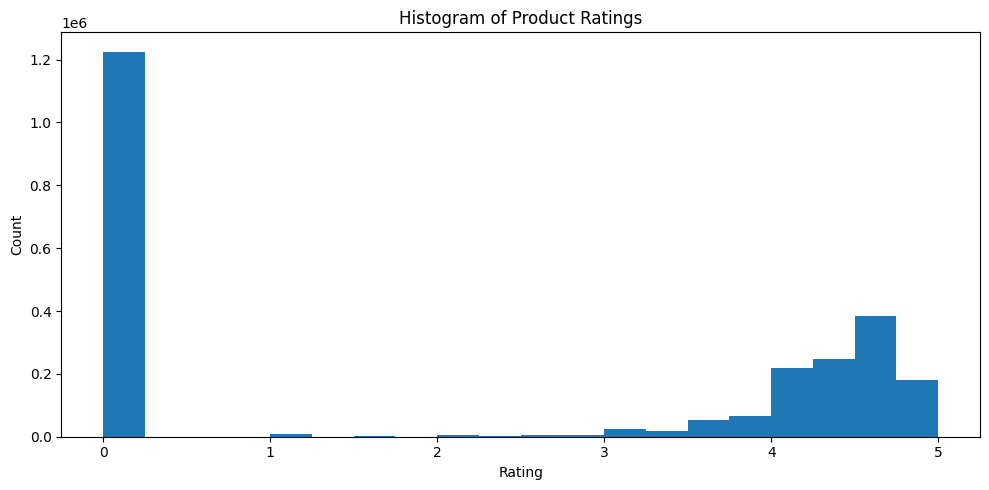


Most common rating values (top 10):
stars
0.0    1225641
4.5     151576
4.6     136990
4.4     136165
5.0     128491
4.3     112563
4.7      94559
4.2      86870
4.0      66089
4.1      65114
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(10, 5))
plt.hist(rating_series, bins=20)
plt.title("Histogram of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Extra: common rating counts (helpful for "is there a specific rating more common?")
rating_counts = rating_series.value_counts().sort_index()
print("\nMost common rating values (top 10):")
print(rating_series.value_counts().head(10))

In [14]:
TOP_K = 10
top_categories = cat_counts.head(TOP_K).index

summary = (
    df_clean[df_clean[category_col].isin(top_categories)]
    .groupby(category_col)
    .agg(
        listings=(category_col, "size"),
        price_mean=(price_col, "mean"),
        price_median=(price_col, "median"),
        rating_mean=(rating_col, "mean"),
        rating_median=(rating_col, "median")
    )
    .sort_values("listings", ascending=False)
)

print("\nTop category summary (listings + price/rating stats):")
print(summary.round(4))


Top category summary (listings + price/rating stats):
                                        listings  price_mean  price_median  rating_mean  rating_median
category                                                                                              
Sports & Outdoors                         836260    125.7706         23.30       0.7351            0.0
Beauty                                     19312     13.2223          8.99       4.3246            4.4
Handmade Clothing, Shoes & Accessories     19229     16.8658          8.99       1.0533            0.0
Bath & Body                                19092     15.0423         11.70       3.9848            4.4
Birthday Gifts                             18978     26.5852         14.25       1.9192            0.0
Manicure & Pedicure Products               18940     10.5211          7.50       3.7403            4.2
Skin Care                                  18769     16.3409         12.00       4.1412            4.4
Make-up           


Price band counts (quantile-based):
price_band
Band 1    629219
Band 2    593028
Band 3    612341
Band 4    365541
Band 5    243502
Name: count, dtype: int64


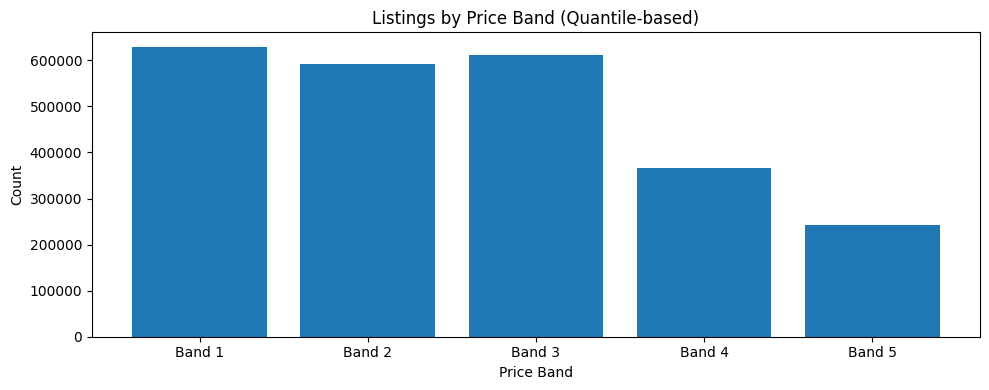

In [15]:
# Create price bands based on quantiles (authentic, data-driven)
bands = price_series.quantile([0, 0.25, 0.5, 0.75, 0.9, 1.0]).values
bands = np.unique(bands)  # avoid duplicates
labels = [f"Band {i+1}" for i in range(len(bands)-1)]

df_priceband = df_clean.copy()
df_priceband = df_priceband[df_priceband[price_col].notna()]
df_priceband["price_band"] = pd.cut(df_priceband[price_col], bins=bands, labels=labels, include_lowest=True)

band_counts = df_priceband["price_band"].value_counts().sort_index()
print("\nPrice band counts (quantile-based):")
print(band_counts)

plt.figure(figsize=(10, 4))
plt.bar(band_counts.index.astype(str), band_counts.values)
plt.title("Listings by Price Band (Quantile-based)")
plt.xlabel("Price Band")
plt.ylabel("Count")
plt.tight_layout()
plt.show()